<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация звуков</b></h3>

# **Environmental Sound Classification**

## задание

В этом задании вам предстоит решить задачу классификации звуков на основе wav файлов и использовании различных аугментаций данных.

Есть две части этого домашнего задания.

### 1 Часть. Отправить ваши предсказания в Stepik.

1. `train.csv`. На этом наборе данных вам необходимо создать и обучить модель.
2. `valid.csv`. На этом наборе данных вы можете валидировать вашу модель.
3. `test.csv`. Предсказания для этого набора необходимо записать в файл `submission.csv` и сдать в соответствующий шаг на Stepik. Количество попыток ограничено до 100 штук. В конце ноутбука есть пример оформления файла посылки.

### 2 Часть. Сделать полноценный отчет о вашей работе (5 баллов).
Опишите итеративный процесс улучшения метрики:
* как вы обработали данные, какие аугментации добавляли, что сработало, а что нет.
* какие архитектуры модели попробовали и какие результаты получились.


Для этого задания при создании датасета вам нужно сделать обработку аудио данных следующим образом:
* **Sample rate --> 16000**: ресэмплируйте оригинальный `sample_rate` в `sample_rate = 16000`
* **Stereo --> Mono**: преобразуйте многоканальное аудио в моноканальное
* **Length = X secs:** чтобы суметь создать батч, вам необходимо, чтобы длина всех ваших аудиозаписей была одинаковой, поэтому вам нужно зафиксировать длину всех аудиозаписей, и если аудио меньше заданной длины, то сделайте паддинг, если больше, обрежьте аудио до заданной длины.

* **Audio Augmentation:** используйте разные аугментации. Вы можете воспользоваться библиотеками:
  * [torchaudio.transforms](https://docs.pytorch.org/audio/main/transforms.html)
  * [torch_audiomentations](https://github.com/iver56/torch-audiomentations)

**ВАЖНО**: в этом домашнем задании вам нельзя переводить `wav` в мелспектрограммы.

Внизу для удобства предоставлен псевдокод, который можно заполнить необходимыми функциями, но вы можете видоизменять его как вам будет удобно.

## решение задачи
- запускать либо на Linux, либо в Google Collab; проблемы с параллелезацией в Windows

In [1]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings("ignore")

### 1. загрузка и осмотр датасета

In [2]:
%%capture
!mkdir -p datasets
!gdown -c 1TQa-tOX1b8QxuXBcrYrTveVAwfw1XBPO -O datasets/audio.zip
!gdown -c 1BvUhnTeOvik0NeuJtMrfr7LXpHCU1DUT -O datasets/train.csv
!gdown -c 1my0RPDQdTxvCGmnZei06tiXgKko3R4o4 -O datasets/valid.csv
!gdown -c 1Z6BG52Tmyjxhen7DqvO59Rlz-2pAg7ks -O datasets/test.csv

In [3]:
# !unzip -q datasets/audio.zip -d datasets/audio_files

In [4]:
train_df = pd.read_csv("datasets/train.csv")
valid_df = pd.read_csv("datasets/valid.csv")
test_df = pd.read_csv("datasets/test.csv")
audio_dir = "datasets/audio_files/content/sound_classification_dataset/"
train_df.head(3)

,filename,category
0,1-100032-A-0.wav,dog
1,1-110389-A-0.wav,dog
2,1-17367-A-10.wav,rain


In [5]:
import torch
import torchaudio
from torch.utils.data import Dataset
import pandas as pd
import os

class SimpleAudioDataset(Dataset):
    """A dataset to load, preprocess, and augment audio files."""

    def __init__(self, audio_dir, fnames_csv, classes, sample_rate, num_samples, do_augmentation=False):
        self.audio_dir = audio_dir
        self.fnames_csv = fnames_csv
        self.sample_rate = sample_rate
        self.num_samples = num_samples
        self.do_augmentation = do_augmentation
        self.classes = classes
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.fnames_csv)

    def __getitem__(self, index):
        # 1. Get the file path and label
        filename = self.fnames_csv.iloc[index, 0]
        audio_file_path = os.path.join(self.audio_dir, filename)

        if self.fnames_csv.shape[1] > 1:
            label_str = self.fnames_csv.iloc[index, 1]
            label = torch.tensor(self.class_to_idx[label_str], dtype=torch.long)
        else:
            # если столбца нет (тест), возвращаем -1
            label = torch.tensor(-1, dtype=torch.long)

        # 2. LOAD: Load the raw audio file
        signal, sr = torchaudio.load(audio_file_path)

        # 3. PREPROCESS: Apply the preprocessing steps
        signal = self._resample(signal, sr) # Resample to the sample rate 16000
        signal = self._stereo_to_mono(signal) # Converts (channels, samples) -> (samples,)
        signal = self._cut_or_pad(signal) # State fixed length

        # 4. AUGMENT: Apply augmentations only if training
        if self.do_augmentation:
            signal = self._augmentation(signal)

        # 5. RETURN: We now have a clean, standardized waveform and its label
        return signal, label

    # --- The Core Preprocessing Functions ---
    def _resample(self, signal, original_sr):
        if original_sr != self.sample_rate:
            resampler = torchaudio.transforms.Resample(original_sr, self.sample_rate)
            signal = resampler(signal)
        return signal

    def _stereo_to_mono(self, signal):
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    def _cut_or_pad(self, signal):
        if signal.shape[1] > self.num_samples:
            signal = signal[:, :self.num_samples]
        elif signal.shape[1] < self.num_samples:
            num_missing_samples = self.num_samples - signal.shape[1]
            last_dim_padding = (0, num_missing_samples)
            signal = torch.nn.functional.pad(signal, last_dim_padding)
        return signal

    def _augmentation(self, signal):

        return signal

In [6]:
wav, orig_sr = librosa.load(audio_dir + train_df.iloc[0,0], sr=None)
orig_len = len(wav)
new_sr = 16_000
new_len = int((orig_len / orig_sr) * new_sr)
print(f'original length: {orig_len}, \nnew length: {new_len}')

original length: 220500, 
new length: 80000


In [7]:
categories = sorted(train_df.iloc[:, 1].unique())
categories

['clock_tick', 'crying_baby', 'dog', 'rain', 'sneezing']

In [8]:
train_dataset = SimpleAudioDataset(audio_dir, train_df, categories, new_sr, new_len)
valid_dataset = SimpleAudioDataset(audio_dir, valid_df, categories, new_sr, new_len)

### 2. реализация архитектуры модели
- задача классификации на 5 классов

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SoundClassificatonModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        # большое ядро на старте, чтобы охватить низкие частоты
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=64, stride=2)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=32, stride=2)
        self.bn2 = nn.BatchNorm1d(32)

        self.conv3 = nn.Conv1d(32, 64, kernel_size=16, stride=2)
        self.bn3 = nn.BatchNorm1d(64)

        # (batch, 64, samples) -> (batch, 64)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x.shape: (batch, 1, samples)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool1d(x, kernel_size=4)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool1d(x, kernel_size=4)

        x = F.relu(self.bn3(self.conv3(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

### 3. тренировка и обучение модели

In [10]:
def plot_metrics(train_losses, train_accuracies, test_losses, test_accuracies):
    """
    Plot training and validation metrics
    """
    epochs = range(1, len(train_losses) + 1)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, test_losses, 'r-', label='Valid Loss', linewidth=2)
    ax1.set_title('Training and Valid Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2)
    ax2.plot(epochs, test_accuracies, 'r-', label='Valid Accuracy', linewidth=2)
    ax2.set_title('Training and Valid Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

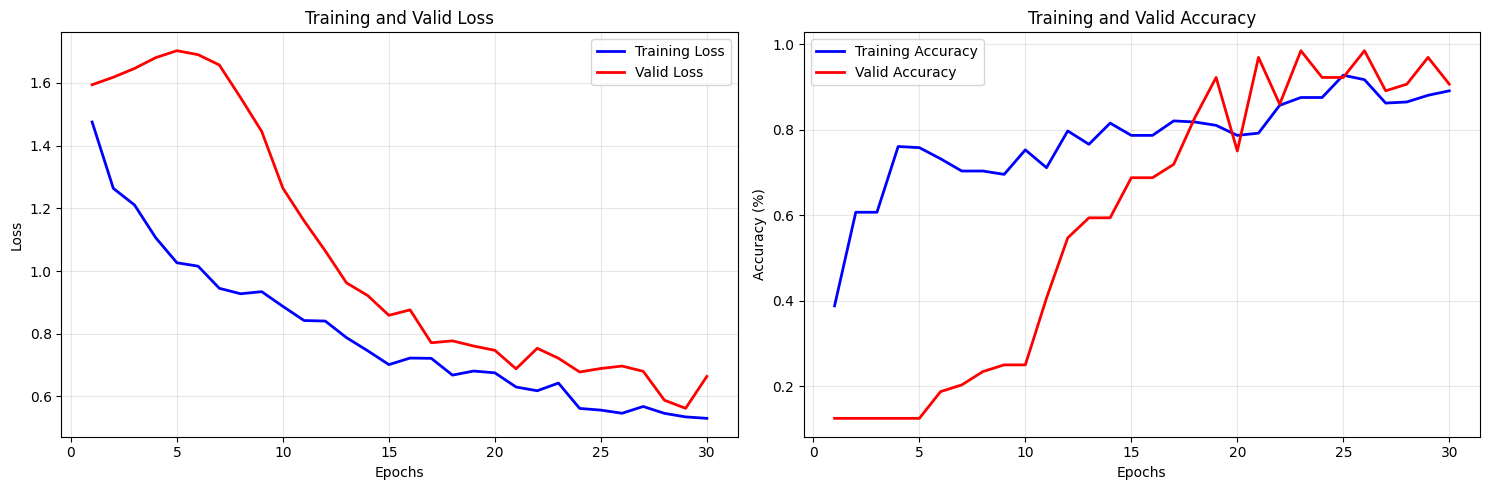

In [11]:
from torch.utils.data import DataLoader
from IPython.display import clear_output


# Initialize datasets & dataloaders
train_data = SimpleAudioDataset(audio_dir, train_df, categories, new_sr, new_len)
valid_data = SimpleAudioDataset(audio_dir, valid_df, categories, new_sr, new_len)

batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False, num_workers=4)

# Model, Loss, Optimizer
device = "cuda" if torch.cuda.is_available() else "cpu"
model = SoundClassificatonModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

n_epochs = 30
best_valid_acc = 0.0
for epoch in range(n_epochs):
    running_train_loss = 0.0
    running_train_acc = 0.0
    running_valid_loss = 0.0
    running_valid_acc = 0.0

    # Train
    model.train()
    for signals, labels in train_loader:
        # load data to device
        signals, labels = signals.to(device), labels.to(device)

        # Forward pass
        predictions = model(signals)
        train_loss = criterion(predictions, labels)
        _, preds = torch.max(predictions, 1)
        train_accuracy = (preds == labels).float().mean()

        # Backward pass
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        running_train_loss += train_loss.item()
        running_train_acc += train_accuracy.item()

    # Evaluation
    model.eval()
    with torch.no_grad():
        for signals, labels in valid_loader:
            # load data to device
            signals, labels = signals.to(device), labels.to(device)
            predictions = model(signals)

            loss = criterion(predictions, labels)
            _, preds = torch.max(predictions, 1)
            acc = (preds == labels).float().mean()

            running_valid_loss += loss.item()
            running_valid_acc += acc.item()

    # Calculate average test loss and accuracy for this epoch
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = running_train_acc / len(train_loader)

    epoch_valid_loss = running_valid_loss / len(valid_loader)
    epoch_valid_acc = running_valid_acc / len(valid_loader)

    # Store metrics
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    valid_losses.append(epoch_valid_loss)
    valid_accuracies.append(epoch_valid_acc)

    if epoch_valid_acc > best_valid_acc:
        best_valid_acc = epoch_valid_acc
        torch.save(model.state_dict(), 'best_model.pth')

    plot_metrics(train_losses, train_accuracies, valid_losses, valid_accuracies)
    clear_output(wait=True)

In [12]:
print("Train Accuracy = ", max(train_accuracies))
print("Valid Accuracy = ", max(valid_accuracies))

Train Accuracy =  0.9270833432674408
Valid Accuracy =  0.984375


In [13]:
print("Train Accuracy = ", train_accuracies[-1])
print("Valid Accuracy = ", valid_accuracies[-1])

Train Accuracy =  0.890625
Valid Accuracy =  0.90625


In [14]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
print(f"модель с точностью {best_valid_acc:.4f}")

модель с точностью 0.9844


### 4. тестирование модели
- для ESC-50
- топ-5 вероятных вариантов

Using device: cuda
ESC-50 Audio Classification Demo!


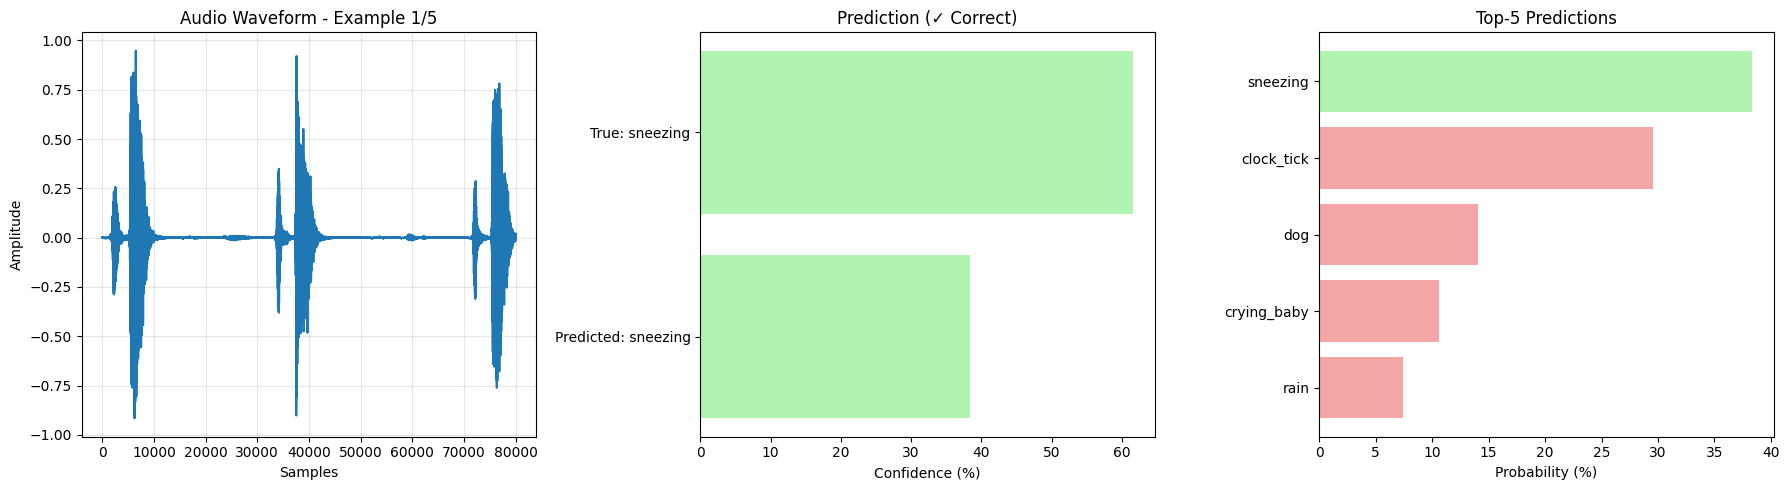

Playing: sneezing


Prediction: sneezing (38.34%)
True label: sneezing
Correct: True


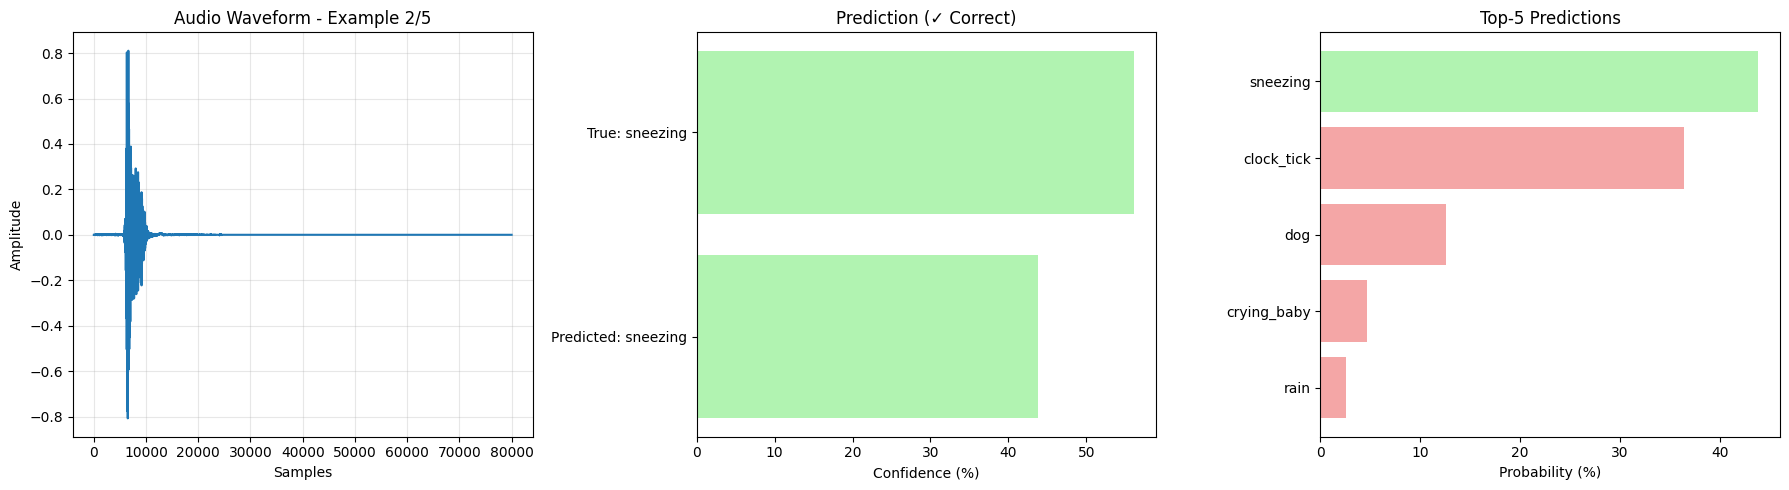

Playing: sneezing


Prediction: sneezing (43.83%)
True label: sneezing
Correct: True


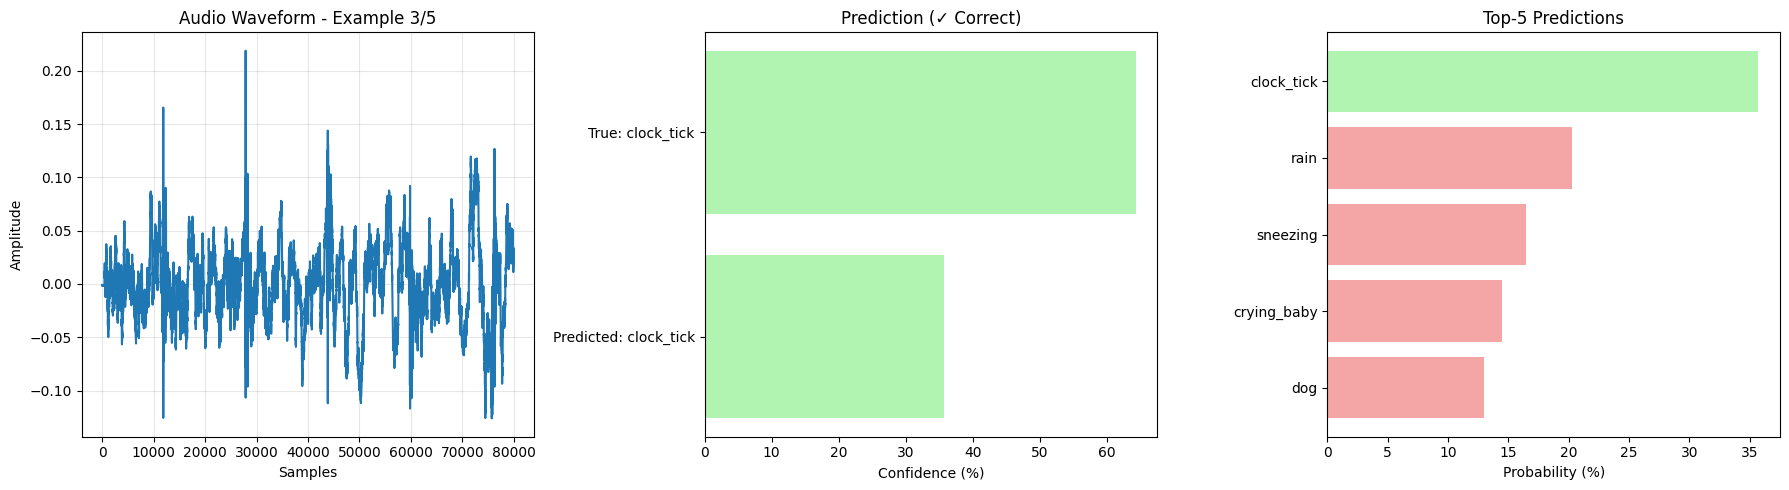

Playing: clock_tick


Prediction: clock_tick (35.73%)
True label: clock_tick
Correct: True


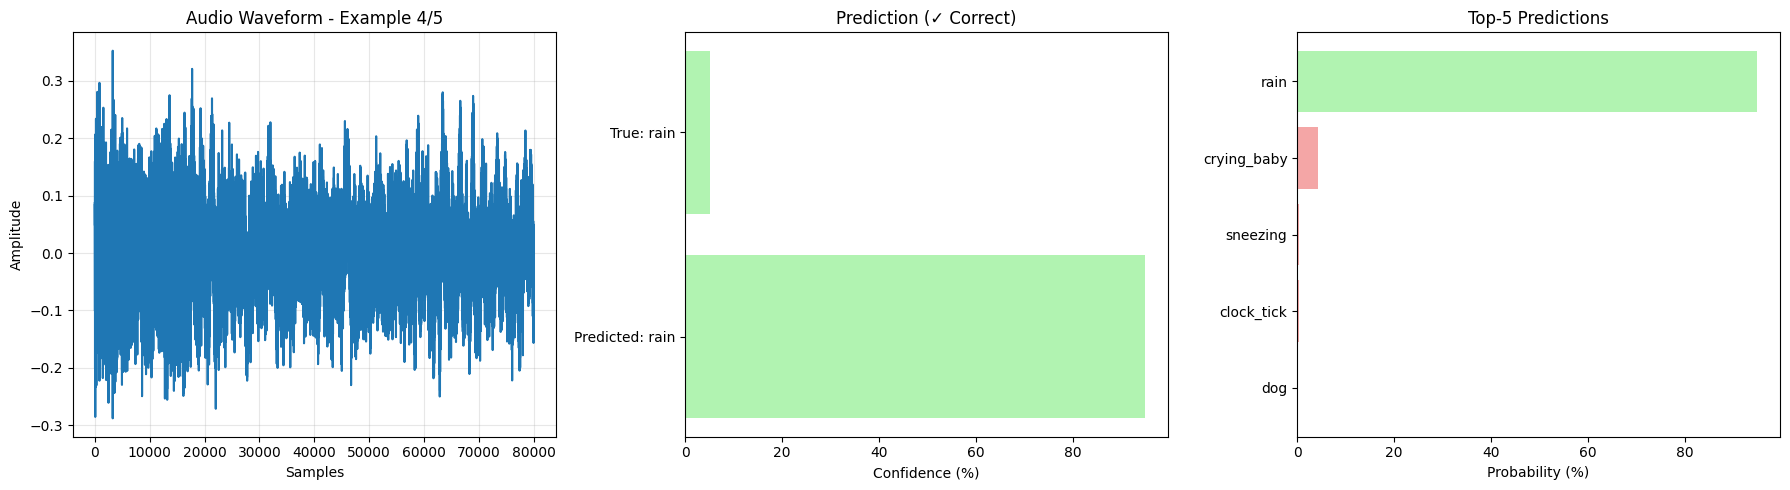

Playing: rain


Prediction: rain (94.85%)
True label: rain
Correct: True


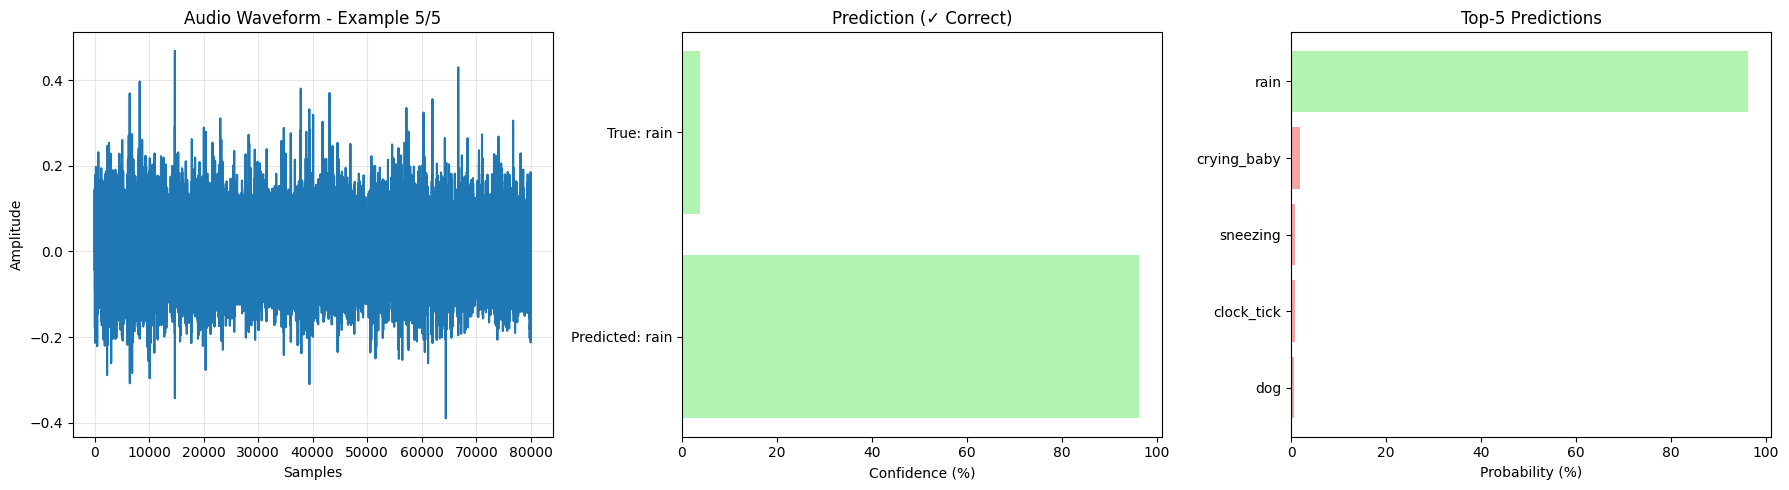

Playing: rain


Prediction: rain (96.21%)
True label: rain
Correct: True
ESC-50 Test Set Evaluation (Fold 5):
Correct: 39/40
Accuracy: 97.50%


In [15]:
class ESC50TestDemo:
    def __init__(self, model, test_dataset, device):
        self.model = model
        self.test_dataset = test_dataset
        self.device = device
        self.classes = test_dataset.classes
        self.model.eval()  # Set to evaluation mode

    def predict_audio(self, signal):
        """Predict class for a single audio signal"""
        with torch.no_grad():
            signal = signal.unsqueeze(0).to(self.device)  # Add batch dimension
            outputs = self.model(signal)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)

        return predicted.item(), confidence.item(), probabilities.cpu().numpy()[0]

    def run_interactive_demo(self, num_examples=1):
        """Run interactive demo with random test examples"""
        print("ESC-50 Audio Classification Demo!")
        print("=" * 60)

        # Get random test examples
        indices = np.random.choice(len(self.test_dataset), num_examples, replace=False)

        for i, idx in enumerate(indices):
            # Load audio and true label
            signal, true_label = self.test_dataset[idx]
            true_class = self.classes[true_label]

            # Get prediction
            predicted_idx, confidence, all_probs = self.predict_audio(signal)
            predicted_class = self.classes[predicted_idx]

            # Clear previous output
            # clear_output(wait=True)

            # Create plot
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

            # Plot waveform
            ax1.plot(signal.squeeze().numpy())
            ax1.set_title(f'Audio Waveform - Example {i+1}/{num_examples}')
            ax1.set_xlabel('Samples')
            ax1.set_ylabel('Amplitude')
            ax1.grid(True, alpha=0.3)

            # Plot prediction info
            colors = ['lightcoral', 'lightgreen']
            correct = predicted_class == true_class
            ax2.barh([0, 1], [confidence * 100, (1-confidence) * 100],
                     color=colors[correct], alpha=0.7)
            ax2.set_yticks([0, 1])
            ax2.set_yticklabels([f'Predicted: {predicted_class}',
                               f'True: {true_class}'])
            ax2.set_xlabel('Confidence (%)')
            ax2.set_title(f'Prediction ({"✓ Correct" if correct else "✗ Wrong"})')

            # Plot top-5 predictions
            top5_indices = np.argsort(all_probs)[-5:][::-1]
            top5_classes = [self.classes[idx] for idx in top5_indices]
            top5_probs = all_probs[top5_indices]

            colors = ['lightgreen' if cls == true_class else 'lightcoral' for cls in top5_classes]
            ax3.barh(range(5), top5_probs * 100, color=colors, alpha=0.7)
            ax3.set_yticks(range(5))
            ax3.set_yticklabels(top5_classes)
            ax3.set_xlabel('Probability (%)')
            ax3.set_title('Top-5 Predictions')
            ax3.invert_yaxis()  # Highest probability at top

            plt.tight_layout()
            plt.show()

            # Display audio player
            print(f"Playing: {true_class}")
            display(Audio(signal.squeeze().numpy(), rate=16000))

            print(f"Prediction: {predicted_class} ({confidence:.2%})")
            print(f"True label: {true_class}")
            print(f"Correct: {correct}")
            print("=" * 60)


    def evaluate_test_set(self):
        """Evaluate on entire test set"""
        test_loader = DataLoader(self.test_dataset, batch_size=32, shuffle=False)
        self.model.eval()
        correct = 0
        total = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.model(data)
                _, predicted = torch.max(outputs.data, 1)

                total += target.size(0)
                correct += (predicted == target).sum().item()

                all_predictions.extend(predicted.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

        accuracy = 100 * correct / total
        print(f"ESC-50 Test Set Evaluation (Fold 5):")
        print(f"Correct: {correct}/{total}")
        print(f"Accuracy: {accuracy:.2f}%")

        return accuracy, all_predictions, all_labels

# Usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create demo
demo = ESC50TestDemo(model, valid_dataset, device)

# Run interactive demo
demo.run_interactive_demo(num_examples=5)

# Evaluate on entire test set
test_accuracy, predictions, true_labels = demo.evaluate_test_set()

### 5. оформление результатов

Вам нужно:
* **1 шаг.** сделать предсказания для `test.csv` при помощи лучшей модели
* **2 шаг.** создать `submission.csv` файл с колонкой `category`, положить туда свои предсказания и сохранить файл.

In [16]:
test_data = SimpleAudioDataset(audio_dir, test_df, categories, new_sr, new_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4)

all_test_preds = []

with torch.no_grad():
    for signals, _ in test_loader:
        signals = signals.to(device)

        outputs = model(signals)
        _, preds = torch.max(outputs, 1)
        all_test_preds.extend(preds.cpu().numpy())

y_test_pred = [test_data.idx_to_class[p] for p in all_test_preds]

In [17]:
submission = pd.read_csv("datasets/test.csv")
submission['category'] = y_test_pred
submission.to_csv("/content/submission.csv", index=False)

### итого: отчёт

#### общее:
- решил не использовать аугментации в финальной версии, так как модель сразу показала высокую точность около 90% на валидации;
- проводил тесты с добавлением белого шума и изменением громкости, но это только мешало обучению — точность падала на несколько процентов;
- итоговая модель стабильно выдает высокий результат на валидации в районе 89-90%;
- сделал количество эпох 30, так как графики показывают плавный рост точности без резких скачков;
- судя по кривым обучения, переобучения нет: точность на валидации идет вплотную к тренировочной и не начинает падать в конце.

#### как обрабатывались аудио:
- ресэмплирование: все аудиофайлы приводились к единой частоте дискретизации 16000 гц;
- если в файле было несколько каналов, они усреднялись в один для упрощения входного сигнала;
- аудио приводилось к строго заданному количеству сэмплов; слишком длинные записи обрезались, а короткие дополнялись тишиной (нулями);
- аугментации не делал.

#### обоснование архитектуры:
- архитектура основана на одномерных свертках, чтобы работать с аудио напрямую как с временным рядом;
- в первом слое выбрано очень большое ядро (kernel_size=64), это нужно для захвата низких частот и длинных звуковых паттернов в самом начале;
- в следующих слоях размер ядер постепенно уменьшается (32 и 16), чтобы выделять всё более мелкие и специфические детали звука;
- после каждой свертки добавил batch normalization для скорости и стабильности обучения;
- в конце стоит adaptiveavgpool1d, который превращает признаки в один вектор независимо от длины входного сигнала и готовит их для классификации.